In [1]:
### IMPORTS
import numpy as np
from scipy import stats
import torch
import swyft
import os
import pickle
from scipy.linalg import solve_triangular

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc
import matplotlib as mpl

use_latex = True
if use_latex:
    os.environ['PATH'] = "/home/abellan/texlive/2025/bin/x86_64-linux:" + os.environ['PATH']
    rc('text', usetex=True)
    rc('font', **{'family': 'serif', 'serif': ['cmr10']})
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{{amsmath}}'

DEVICE = 'gpu' if torch.cuda.is_available() else 'cpu'  

/home/awernersson/venvs/tmnre/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
### Import from merlin
from simulator_utils import Simulator, get_sigmas_bounds
import configparser

In [ ]:
### Load config
config_path = '/home/awernersson/projects/merlin/examples/old_config.ini'
config = configparser.ConfigParser()
config.read(config_path)

['/home/awernersson/projects/merlin/examples/old_config.ini']

In [3]:
obs = np.load(
        config["OBSERVATION"]["obs"], allow_pickle=True
).item()

Nbin_z = int(config["FINV"]["Nbin_z"])
N_spectra = Nbin_z*(2*Nbin_z+1)
N_ell = int(config["FINV"]["N_ell"])

ell_theory = np.load(
        config["AUX FILES"]["ell_file"]
)


In [5]:
WL_keys = [("SHE", "SHE", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(i, Nbin_z + 1)]

GG_keys = [("POS", "POS", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(i, Nbin_z + 1)]

GGL_keys = [("POS", "SHE", i, j)
    for i in range(1, Nbin_z + 1)
    for j in range(1, Nbin_z + 1)]

n_WL = len(WL_keys)
n_GGL = len(GGL_keys)
n_GC = len(GG_keys)

offset_WL = 0
offset_GGL = n_WL
offset_GC = n_WL + n_GGL

cells_sim = obs['C_ells']
noise_sim = obs['noise']

#idx_sim = 3000
#cells_sim = store[idx_sim]['C_ells']
#noise_sim = store[idx_sim]['noise']

cells_2d = cells_sim.reshape(N_spectra, N_ell).T
noise_2d = noise_sim.reshape(N_spectra, N_ell).T
ells = ell_theory

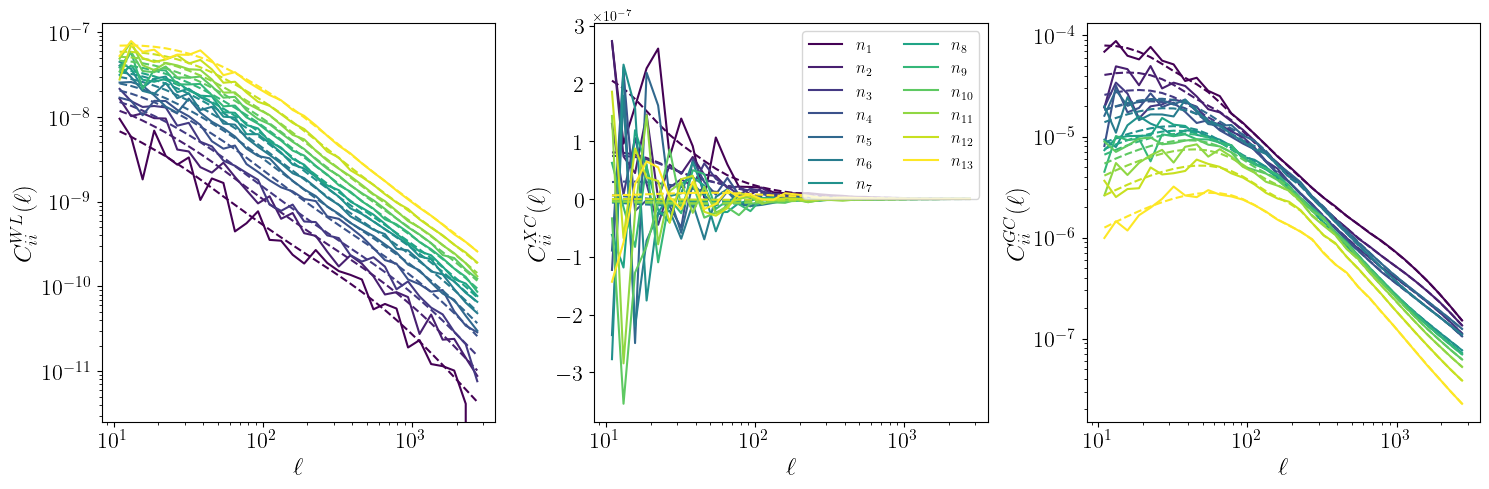

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, Nbin_z))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
plt.subplots_adjust(wspace=0)

for ax_idx, ax in enumerate(axes):
    for i in range(Nbin_z):
        ax.set_xscale('log')
        if ax_idx == 0:
            idx = i*Nbin_z - i*(i-1)//2
            spec_index = offset_WL + idx
            ax.set_ylabel(r'$C^{WL}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('log')
        elif ax_idx == 1:
            idx = i*Nbin_z + i
            spec_index = offset_GGL + idx
            ax.set_ylabel(r'$C^{XC}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('linear')
        else:
            idx = i*Nbin_z - i*(i-1)//2
            spec_index = offset_GC + idx
            ax.set_ylabel(r'$C^{GC}_{ii} (\ell)$', fontsize=18)
            ax.set_yscale('log')
        C_ells = cells_2d[:, spec_index]
        C_ells_noisy = cells_2d[:, spec_index] + noise_2d[:, spec_index]
        ax.plot(ells, C_ells, linestyle='--', color=colors[i])
        ax.plot(ells, C_ells_noisy, linestyle='-', color=colors[i],label=rf'$n_{{{i+1}}}$' if ax_idx == 1 else None)  

    ax.set_xlabel(r'$\ell$', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)

axes[1].legend(loc='upper right', ncol=2, fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

# Validate training

In [4]:
from training_utils import Network


V_proj = np.load(
        config["PCA"]["SVD"],
        allow_pickle = True
)
network = Network(V_proj)

Using 391 PCA components


In [ ]:
import pickle
    
with open("/gpfs/scratch1/shared/awernersson/swyft_cloelib/predictions/merlin_cosmo_predictions_22March_newgen_noiseless.pkl", "rb") as f:
    predictions = pickle.load(f)
print("Predictions loaded using pickle.")

Predictions loaded using pickle.


In [6]:
### Add MCMC
# ---- Load MCMC chain ----
from getdist import MCSamples
data    = np.load('/gpfs/scratch1/shared/awernersson/swyft_cloelib/MCMC/guada_chains.hdf5',
                  allow_pickle=True)
chain   = data['chain'].item()
weights = data['weights'] if 'weights' in data else np.ones(len(chain['H0']))
log_w   = weights - weights.max()
w_norm  = np.exp(log_w); w_norm /= w_norm.sum()

mcmc_keys = ['H0', 'Omega_b0', 'Omega_cdm0', 'ns', 'logAs']
chain_2d  = np.column_stack([chain[k] for k in mcmc_keys])
rng       = np.random.default_rng(42)
idx_mc    = rng.choice(len(chain_2d), size=50_000, replace=True, p=w_norm)
chain_r   = chain_2d[idx_mc]
samples = MCSamples(samples=chain_r, names=mcmc_keys)

Removed no burn in


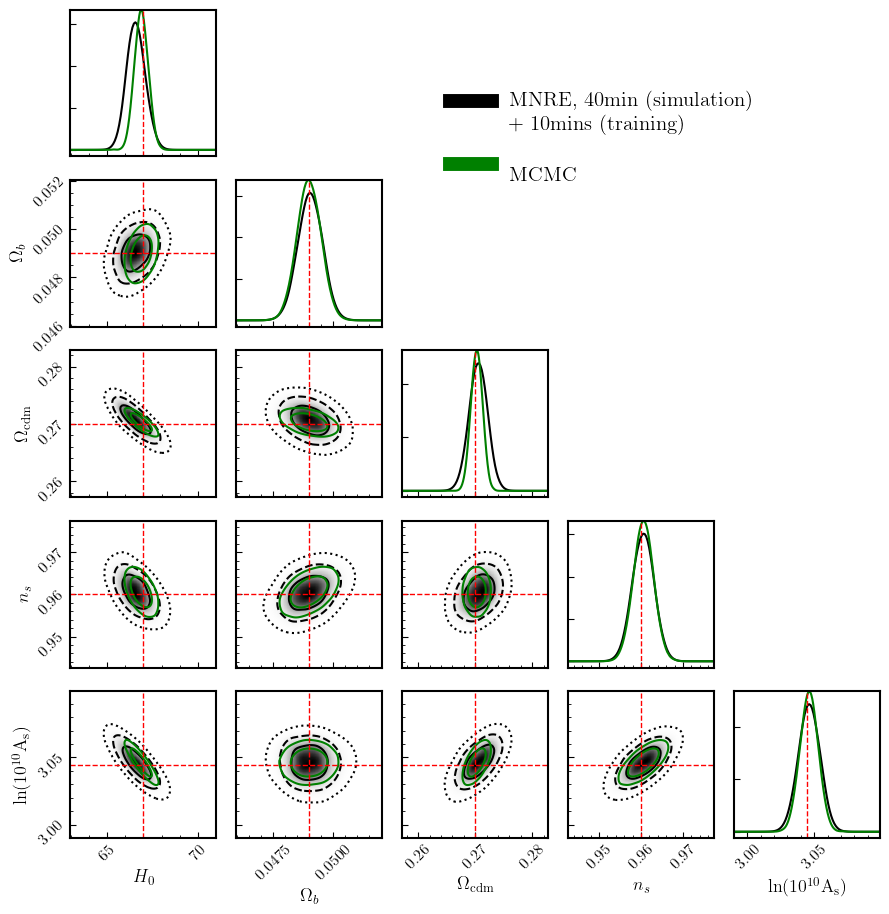

In [11]:
%matplotlib inline
N_plot = network.num_params_show
fig, axes = plt.subplots(N_plot, N_plot, figsize=(9,9))
color_swyft='black'
color_mcmc='green'
color_fid = 'red'
fontsize_tick = 11

# corner plot with swyft predictions
plot_pars = [r'$H_0$', r'$\Omega_b$', r'$\Omega_{\rm cdm}$', r'$n_s$', r'$\rm{ln}(10^{10}A_s)$']
swyft.plot_corner(predictions, ('z[0]', 'z[1]', 'z[2]','z[3]','z[4]'),
                  color=color_swyft, fig=fig, bins=100, smooth=2, contours_1d=False)

# ---- MCMC overlay via GetDist ----
# Save swyft axis limits before GetDist touches anything
xlims = [axes[i, i].get_xlim() for i in range(N_plot)]
ylims_diag = [axes[i, i].get_ylim() for i in range(N_plot)]
ylims_off = {(j, i): axes[j, i].get_ylim() for i, j in network.marginals}
xlims_off = {(j, i): axes[j, i].get_xlim() for i, j in network.marginals}

for i in range(N_plot):
    # 1D marginals on diagonal
    density = samples.get1DDensity(mcmc_keys[i])
    xs = np.linspace(*xlims[i], 500)
    ys = density.Prob(xs)
    if ys.max() > 0:
        ys = ys / ys.max() * ylims_diag[i][1]
    axes[i, i].plot(xs, ys, color=color_mcmc, lw=1.5)
    axes[i, i].set_xlim(xlims[i])
    axes[i, i].set_ylim(ylims_diag[i])

for i, j in network.marginals:
    # 2D contours on off-diagonal
    density2d = samples.get2DDensity(mcmc_keys[i], mcmc_keys[j], normalized=True)
    xs = np.linspace(*xlims_off[(j, i)], 200)
    ys = np.linspace(*ylims_off[(j, i)], 200)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = density2d.Prob(XX, YY)
    levels = sorted(density2d.getContourLevels([0.68, 0.95]))
    axes[j, i].contour(XX, YY, ZZ, levels=levels, colors=color_mcmc, linewidths=1.5)
    axes[j, i].set_xlim(xlims_off[(j, i)])
    axes[j, i].set_ylim(ylims_off[(j, i)])
# ----------------------------------

for i in range(N_plot): 
    axes[i, i].axvline(obs['z'][i], color=color_fid, lw=1., linestyle='dashed')
    axes[i, i].minorticks_on()
    axes[i, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[i, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2, left=False)
    
for i, j in network.marginals: 
    axes[j, i].axvline(obs['z'][i], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].axhline(obs['z'][j], color=color_fid, lw=1., linestyle='dashed')
    axes[j, i].minorticks_on()
    axes[j, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[j, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    
for i in range(N_plot):
    axes[N_plot-1, i].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, rotation=45, size=4)
    axes[N_plot-1, i].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[N_plot-1, i].set_xlabel(plot_pars[i], fontsize=13)
    axes[N_plot-1, i].minorticks_on()
for i in range(1, N_plot):
    axes[i, 0].set_ylabel(plot_pars[i], fontsize=13)
for i in range(1, N_plot):
    axes[i, 0].tick_params(axis='both', which='major', direction="in", labelsize=fontsize_tick, size=4)
    axes[i, 0].tick_params(axis='both', which='minor', direction="in", labelsize=fontsize_tick, rotation=45, size=2)
    axes[i, 0].minorticks_on()

for i, j in network.marginals:
    [x.set_linewidth(1.5) for x in axes[j, i].spines.values()]
for i in range(N_plot):
    [x.set_linewidth(1.5) for x in axes[i, i].spines.values()]

# updated legend
labels = ['\n MNRE, 40min (simulation) \n + 10mins (training)', '\n MCMC']
colors = [color_swyft, color_mcmc]
alphas = [1., 1.]
lines = [Line2D([0], [0], color=colors[i], alpha=alphas[i], linewidth=10, linestyle='-') 
         for i in range(len(labels))]
plt.legend(lines, labels, loc=(-2.0, 4.4), fontsize=15, frameon=False)

plt.savefig('corner_cosmo_merlin_vs_MCMC.pdf')
plt.show()

# Coverage tests